<a href="https://colab.research.google.com/github/madhu-sudhana07/madhusudhana/blob/main/Aerofit_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Business Case Study- Aerofit**

**About Aerofit**

Aerofit is a leading brand in the field of fitness equipment. Aerofit provides a product range including machines such as treadmills, exercise bikes, gym equipment, and fitness accessories to cater to the needs of all categories of people.



**Business problem**

The market research team at AeroFit wants to identify the characteristics of the target audience for each type of treadmill offered by the company, to provide a better recommendation of the treadmills to new customers. The team decides to investigate whether there are differences across the product with respect to customer characteristics.


**Understanding the dataset**


*   Product: Product Purchased KP281, KP481, or KP781
*   Age: In years
*   Gender: Male/Female
*   Education: in years
*   MaritalStatus: single or partnered
*   Usage: average number of times the customer plans to use the treadmill each week.
*   Income: annual income (in $)
*   Fitness: self-rated fitness on a 1-to-5 scale, where 1 is poor shape and 5
  is the excellent shape.
*  Miles: average number of miles the customer expects to walk/run each week

**Product Portfolio:**

* The KP281 is an entry-level treadmill that sells for $1,500.

* The KP481 is for mid-level runners that sell for $1,750.

* The KP781 treadmill has advanced features that sell for $2,500.



In [ ]:
#Importing the Necessary Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from scipy import stats

In [ ]:
# Loading the dataset
df=pd.read_csv("/content/aerofit_treadmill.csv")
print(df.head())

  Product  Age  Gender  Education MaritalStatus  Usage  Fitness  Income  Miles
0   KP281   18    Male         14        Single      3        4   29562    112
1   KP281   19    Male         15        Single      2        3   31836     75
2   KP281   19  Female         14     Partnered      4        3   30699     66
3   KP281   19    Male         12        Single      3        3   32973     85
4   KP281   20    Male         13     Partnered      4        2   35247     47


In [ ]:
# Printing the num of rows and columns in the dataframe.
print(f"Number of rows: {df.shape[0]} \nNumber of columns: {df.shape[1]}")

Number of rows: 180 
Number of columns: 9


In [ ]:
# Checking for null values
df.isna().sum()

Product          0
Age              0
Gender           0
Education        0
MaritalStatus    0
Usage            0
Fitness          0
Income           0
Miles            0
dtype: int64

No null values in the dataset

In [ ]:
# Checking the unique values in every column
df.nunique().sort_values(ascending=False)

Income           62
Miles            37
Age              32
Education         8
Usage             6
Fitness           5
Product           3
Gender            2
MaritalStatus     2
dtype: int64

In [ ]:
# Checking for duplicates
df.duplicated().sum()

0

In [ ]:
# Checking Datatypes of Columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB


In [ ]:
# Checking for unique products
df['Product'].unique()

array(['KP281', 'KP481', 'KP781'], dtype=object)

In [ ]:
# statisctical summary of int type columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,180.0,28.788889,6.943498,18.0,24.00,26.0,33.00,50.0
Education,180.0,15.572222,1.617055,12.0,14.00,16.0,16.00,21.0
Usage,180.0,3.455556,1.084797,2.0,3.00,3.0,4.00,7.0
Fitness,180.0,3.311111,0.958869,1.0,3.00,3.0,4.00,5.0
Income,180.0,53719.577778,16506.684226,29562.0,44058.75,50596.5,58668.00,104581.0
Miles,180.0,103.194444,51.863605,21.0,66.00,94.0,114.75,360.0


In [ ]:
# statisctical summary of object type columns
df.describe(include="object").T

,count,unique,top,freq
Product,180,3,KP281,80
Gender,180,2,Male,104
MaritalStatus,180,2,Partnered,107


**Observations:**
*  There are no missing values in the data.
*  There are 3 unique products in the dataset.
*  KP281 is the most frequently bought product.
*  Minimum & Maximum age of customers is 18 & 50, mean is 28.79 and 75% of persons have age less than or equal to 33.
*   Most customers are having 16 years of education i.e., 75% of persons are having education <= 16 years.
*   Out of 180 data points, 104's gender is Male and rest are the female.
*   Standard deviation for Income & Miles is very high. These variables might have the outliers in it.
*   Majority of the customers are partnered.




#Univariate analysis

**Find the outliers for every continuous variable in the dataset**

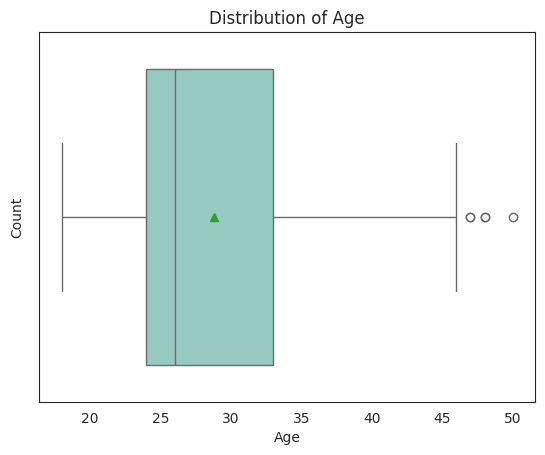

In [ ]:
sns.boxplot(data=df,x="Age",showmeans=True,palette="Set3" )
plt.title("Distribution of Age")
plt.ylabel("Count")
plt.show()
#Shows outlier distribution

Few outliers are observed Distribution of Age.

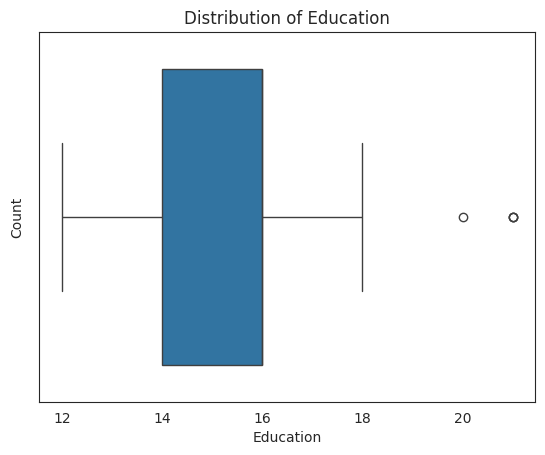

In [ ]:
sns.boxplot(data=df,x="Education")
plt.title("Distribution of Education")
plt.ylabel("Count")
plt.show()
#Shows outlier distribution

Few outliers are observed Distribution of Education.

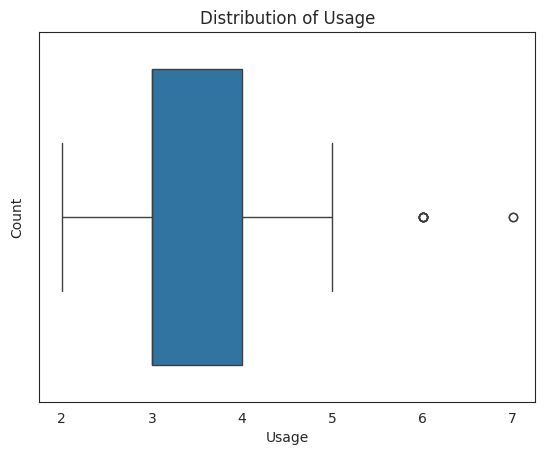

In [ ]:
sns.boxplot(data=df,x="Usage")
plt.title("Distribution of Usage")
plt.ylabel("Count")
plt.show()
#Shows outlier distribution

Few outliers are observed Distribution of Usage.

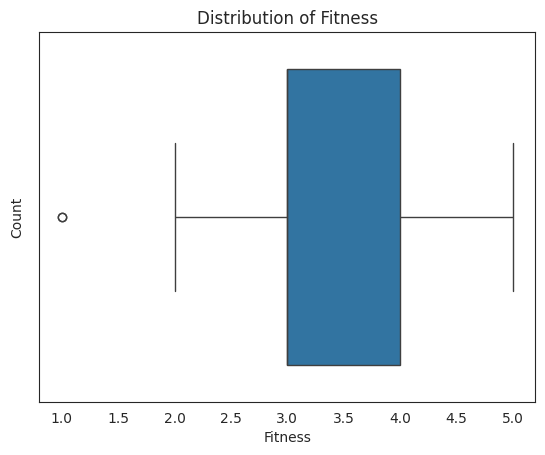

In [ ]:
sns.boxplot(data=df,x="Fitness")
plt.title("Distribution of Fitness")
plt.ylabel("Count")
plt.show()
#Shows outlier distribution

Few outliers are observed Distribution of Fitness.

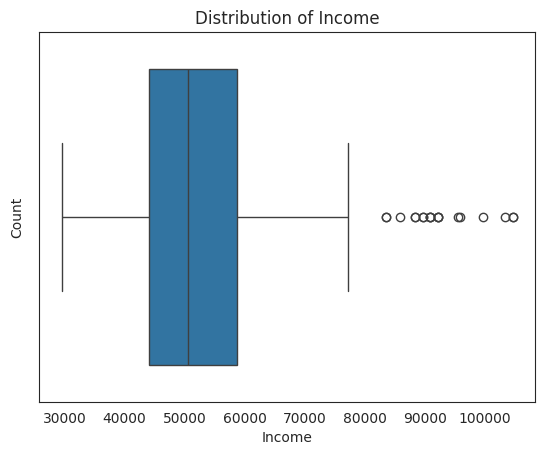

In [ ]:
sns.boxplot(data=df,x="Income")
plt.title("Distribution of Income")
plt.ylabel("Count")
plt.show()
#Shows outlier distribution

More outliers are observed Distribution of Income.

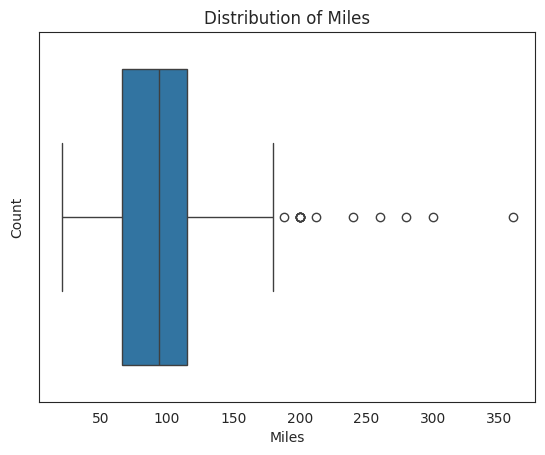

In [ ]:
sns.boxplot(data=df,x="Miles")
plt.title("Distribution of Miles")
plt.ylabel("Count")
plt.show()
#Shows outlier distribution

More outliers are observed in Distribution of Miles.

**Find if there is any relationship between the categorical variables and the output variable in the data.**

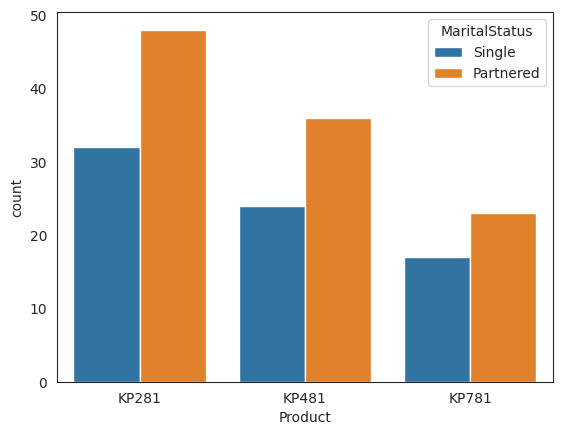

In [ ]:
sns.countplot( data=df, x="Product",hue="MaritalStatus")
plt.show()

KP281 is most prefered product among both the single and partnered customers.

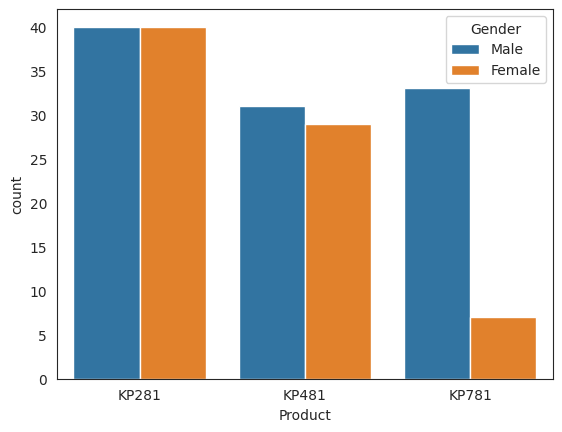

In [ ]:
sns.countplot( data=df, x="Product",hue="Gender")
plt.show()

KP281 is the most prefered product amongst both the genders.

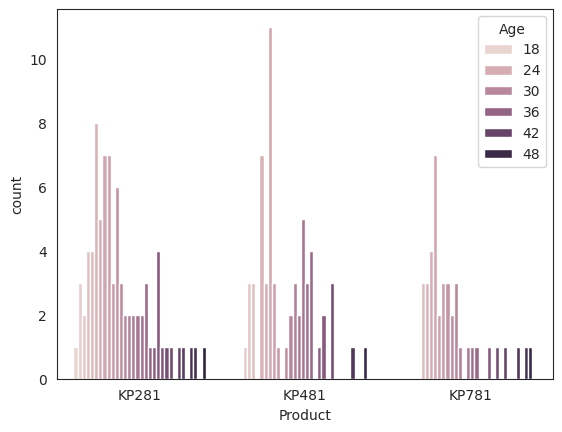

In [ ]:
sns.countplot( data=df, x="Product",hue="Age")
plt.show()

KP281 is the most prefered product across all age group.

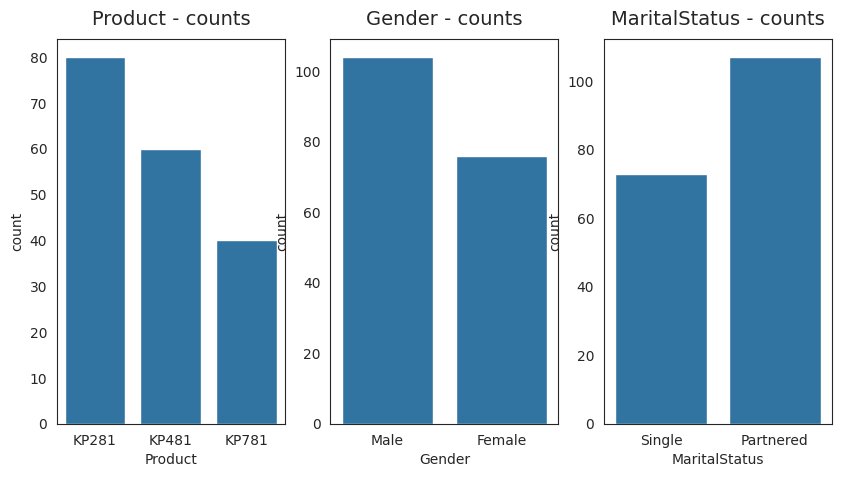

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(10,5))
sns.countplot(data=df, x='Product', ax=axs[0])
sns.countplot(data=df, x='Gender', ax=axs[1])
sns.countplot(data=df, x='MaritalStatus', ax=axs[2])

axs[0].set_title("Product - counts", pad=10, fontsize=14)
axs[1].set_title("Gender - counts", pad=10, fontsize=14)
axs[2].set_title("MaritalStatus - counts", pad=10,
fontsize=14)
plt.show()

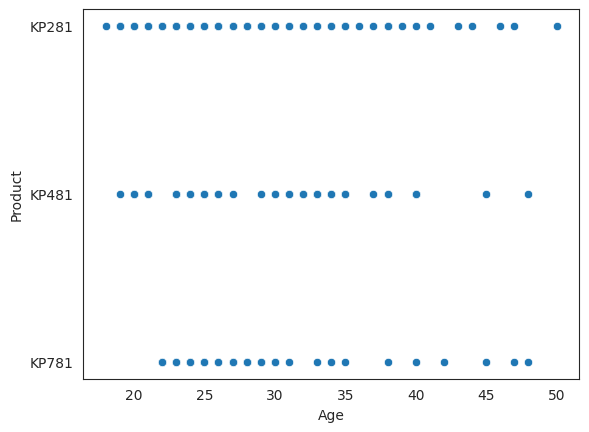

In [ ]:
sns.scatterplot(data=df,x ="Age", y="Product")
plt.show()

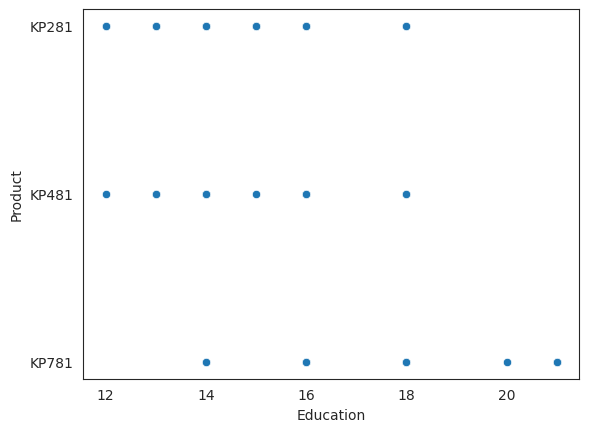

In [ ]:
sns.scatterplot(data=df,x ="Education", y="Product")
plt.show()

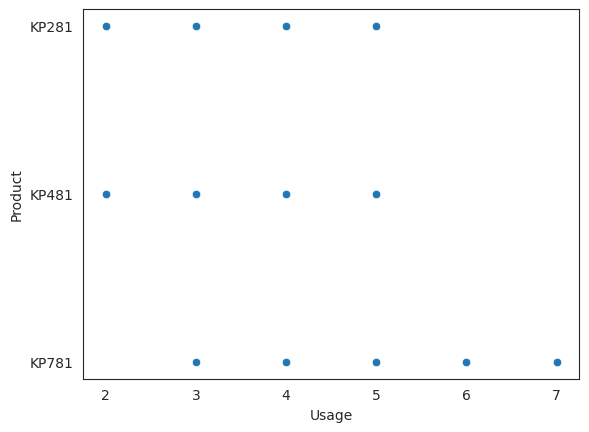

In [ ]:
sns.scatterplot(data=df,x ="Usage", y="Product")
plt.show()

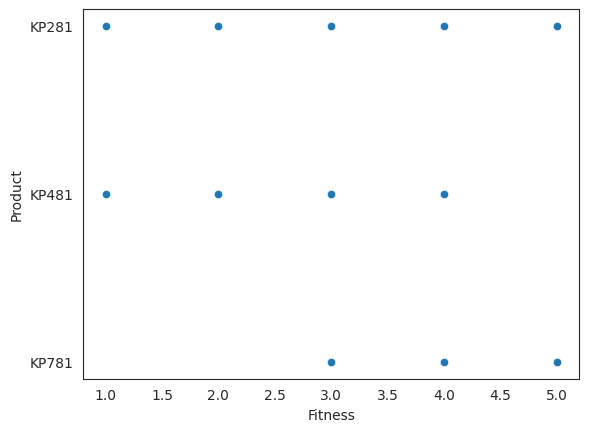

In [ ]:
sns.scatterplot(data=df,x ="Fitness", y="Product")
plt.show()

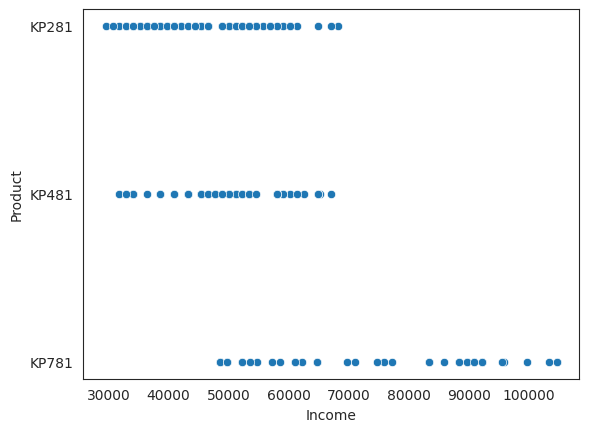

In [ ]:
sns.scatterplot(data=df,x ="Income", y="Product")
plt.show()

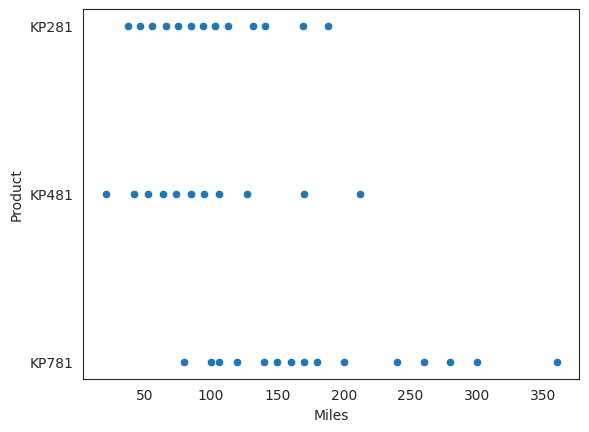

In [ ]:
sns.scatterplot(data=df,x ="Miles", y="Product")
plt.show()

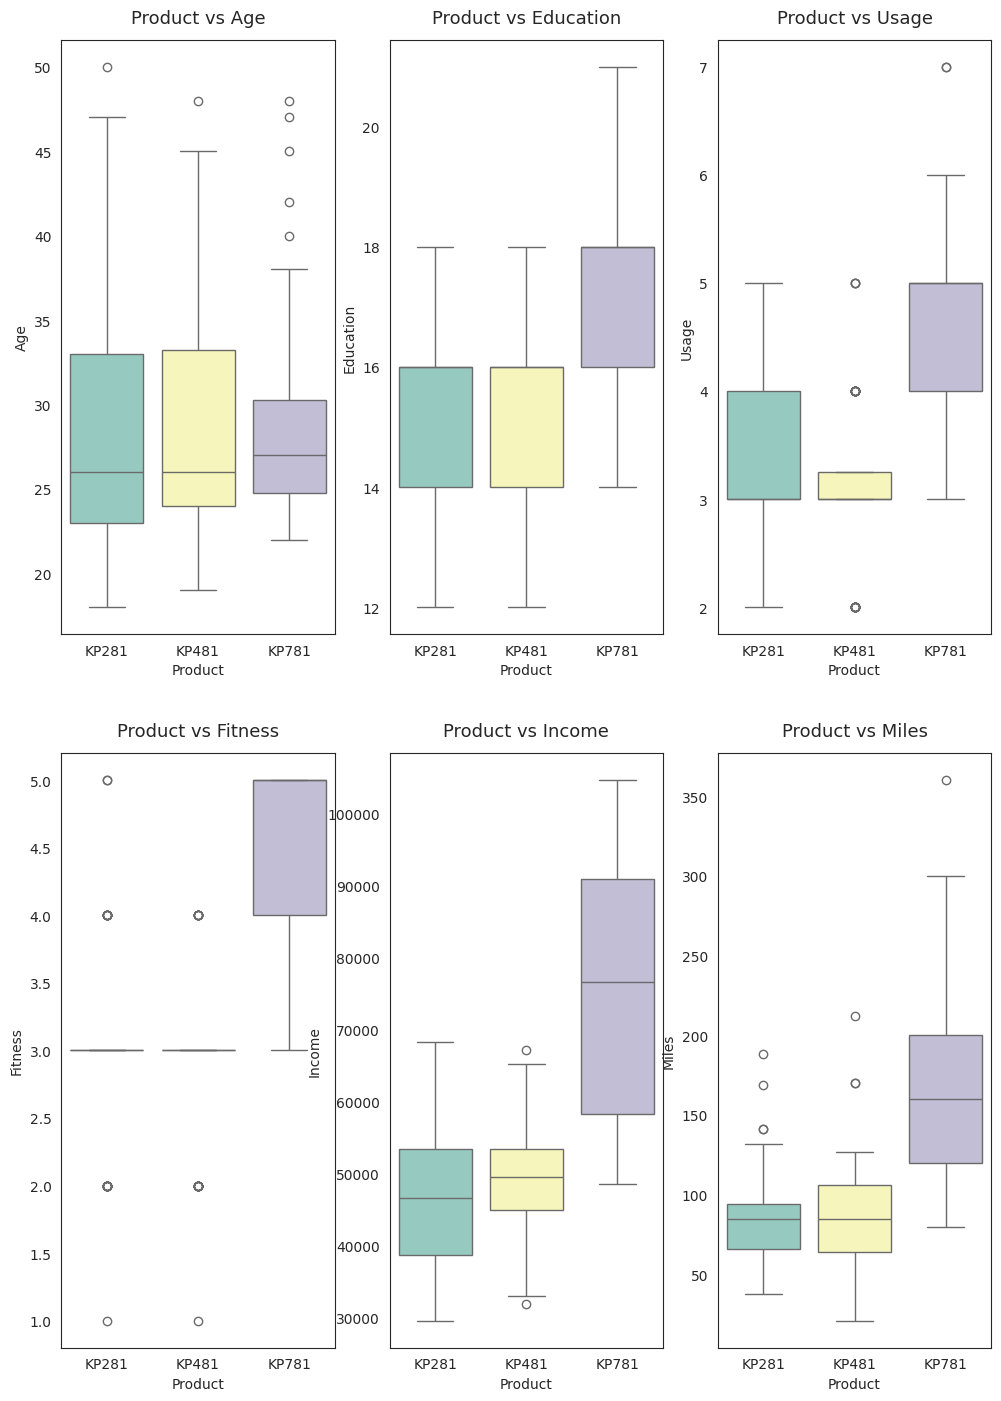

In [ ]:
keys = ['Age', 'Education', 'Usage', 'Fitness', 'Income', 'Miles']
sns.set_style("white")
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(12, 12))
fig.subplots_adjust(top=1.2)
count = 0
for i in range(2):
    for j in range(3):
        sns.boxplot(data=df, x='Product', y=keys[count], ax=axs[i,j], palette='Set3')
        axs[i,j].set_title(f"Product vs {keys[count]}", pad=12, fontsize=13)
        count += 1


**Observations:**

1. Product vs Age

Customers purchasing products KP281 & KP481 are having same Age median
value.

Customers whose age lies between 25-30, are more likely to buy KP781 product

2. Product vs Education

Customers whose Education is greater than 16, are more likely to
purchase the KP781 product.

While the customers with Education less than 16 are equally likely of
purchasing KP281 or KP481.

3. Product vs Usage

Customers who are planning to use the treadmill greater than 4 times a week, are more likely to purchase the KP781 product.

While the other customers are likely to purchasing KP281 or KP481.

4. Product vs Fitness

The more the customer is fit (fitness >= 3), more likely of the customer to purchase the KP781 product.

5. Product vs Income

Higher the Income of the customer (Income >= 60000), more likely of
the customer to purchase the KP781 product.

6. Product vs Miles

If the customer expects to walk/run greater than 120 Miles per week, it is more likely that the customer will buy KP781 product.


#Multivariate Analysis

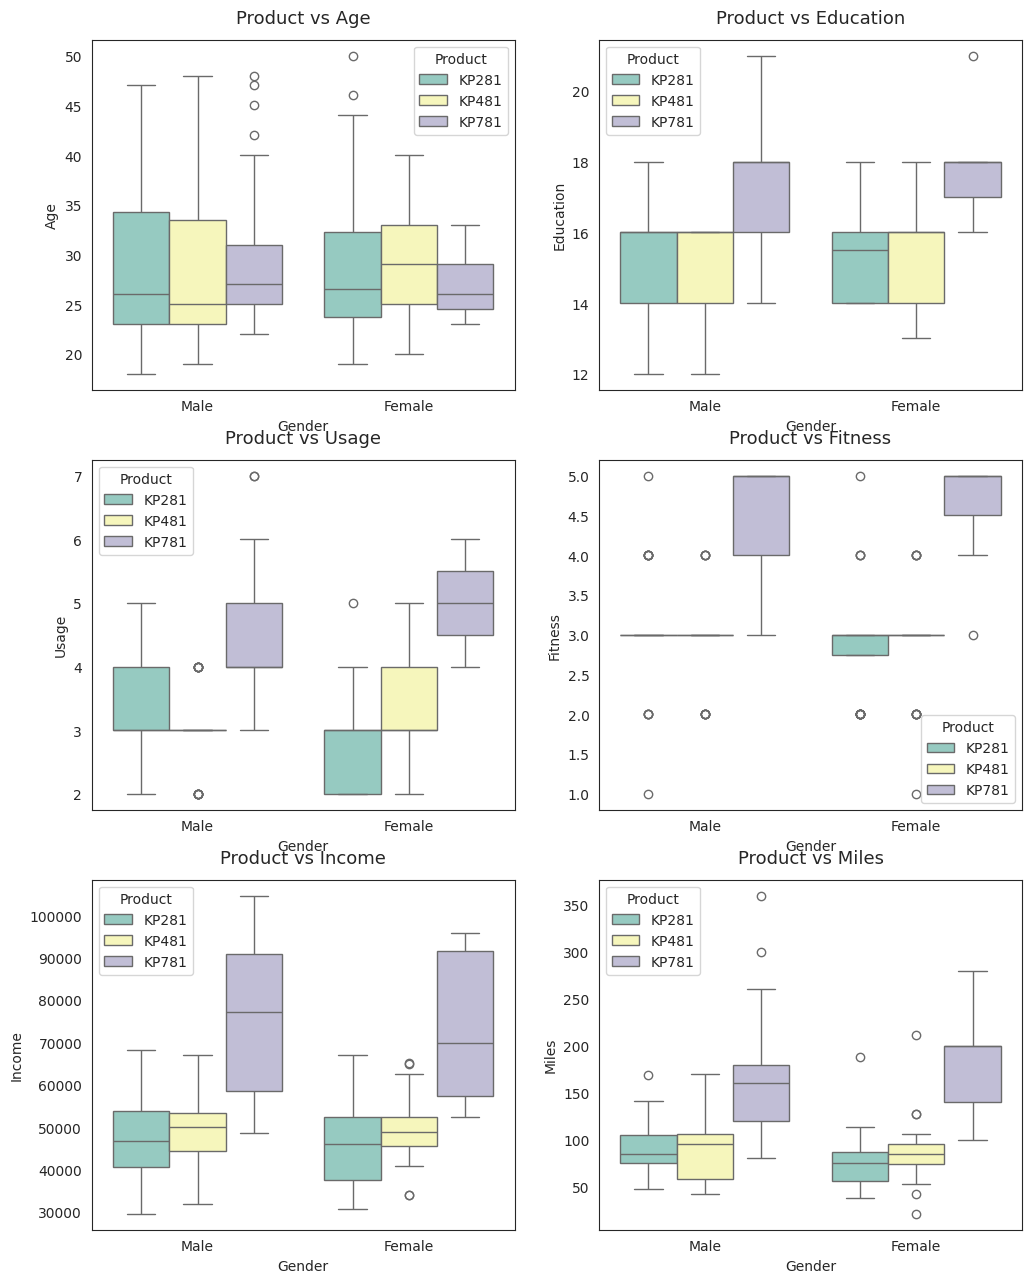

In [ ]:
keys_ = ['Age', 'Education', 'Usage', 'Fitness', 'Income', 'Miles']
sns.set_style("white")
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(12, 10))
fig.subplots_adjust(top=1.3)
count = 0
for i in range(3):
    for j in range(2):
        sns.boxplot(data=df, x='Gender', y=keys_[count], hue='Product', ax=axs[i,j], palette='Set3')
        axs[i,j].set_title(f"Product vs {keys_[count]}", pad=12, fontsize=13)
        count += 1

Females planning to use treadmill 3-4 times a week, are more likely to
buy KP481 product


**Representing the Probability**

In [ ]:
df0 = df[['Product', 'Gender', 'MaritalStatus']].melt()
df0.groupby(['variable', 'value'])[['value']].count() / len(df)
# Checking the probability of Product across Gender and MaritalStatus

value
variable      value              
Gender        Female     0.422222
              Male       0.577778
MaritalStatus Partnered  0.594444
              Single     0.405556
Product       KP281      0.444444
              KP481      0.333333
              KP781      0.222222

In [ ]:
df1 = pd.crosstab(index=df['Gender'], columns=[df['Product']],margins=True)
df1
# Checking using Contingency Table

Product,KP281,KP481,KP781,All
Gender,,,,
Female,40,29,7,76
Male,40,31,33,104
All,80,60,40,180


In [ ]:
#Probability of Male customers in the dataset
print((104/180)*100,"%")

57.77777777777777 %


In [ ]:
#Probability of Female customers in the dataset
print((78/180)*100,"%")

43.333333333333336 %


In [ ]:
# Probability of KP281 bought by a customer
print((80/180)*100,"%")

44.44444444444444 %


In [ ]:
# Probability of KP481 bought by a customer
print((60/180)*100,"%")

33.33333333333333 %


In [ ]:
# Probability of KP781 bought by a customer
print((40/180)*100,"%")

22.22222222222222 %


In [ ]:
# Probability of KP281 bought by a Male customer
print((40/180)*100,"%")

22.22222222222222 %


In [ ]:
# Probability of KP281 bought by a Female customer
print((40/180)*100,"%")

22.22222222222222 %


In [ ]:
# Probability of KP481 bought by a Male customer
print((31/180)*100,"%")

17.22222222222222 %


In [ ]:
# Probability of KP481 bought by a Female customer
print((29/180)*100,"%")

16.11111111111111 %


In [ ]:
# Probability of KP781 bought by a Male customer
print((33/180)*100,"%")

18.333333333333332 %


In [ ]:
# Probability of KP781 bought by a Female customer
print((7/180)*100,"%")

3.888888888888889 %


In [ ]:
# Probability of products bought across MaritalStatus
def p_prod_given_mstatus(status, print_marginal=False):
    if status != "Single" and status != "Partnered":
        return "Invalid marital status value."

    df1 = pd.crosstab(index=df['MaritalStatus'], columns=[df['Product']])
    p_781 = df1['KP781'][status] / df1.loc[status].sum()
    p_481 = df1['KP481'][status] / df1.loc[status].sum()
    p_281 = df1['KP281'][status] / df1.loc[status].sum()

    if print_marginal:
        print(f"P(Single): {df1.loc['Single'].sum()/len(df):.2f}")
        print(f"P(Partnered): {df1.loc['Partnered'].sum()/len(df):.2f}\n")

    print(f"P(KP781/{status}): {p_781:.2f}")
    print(f"P(KP481/{status}): {p_481:.2f}")
    print(f"P(KP281/{status}): {p_281:.2f}\n")

p_prod_given_mstatus('Single', True)
p_prod_given_mstatus('Partnered')

P(Single): 0.41
P(Partnered): 0.59

P(KP781/Single): 0.23
P(KP481/Single): 0.33
P(KP281/Single): 0.44

P(KP781/Partnered): 0.21
P(KP481/Partnered): 0.34
P(KP281/Partnered): 0.45



#Finding the correlation between the given features in the table

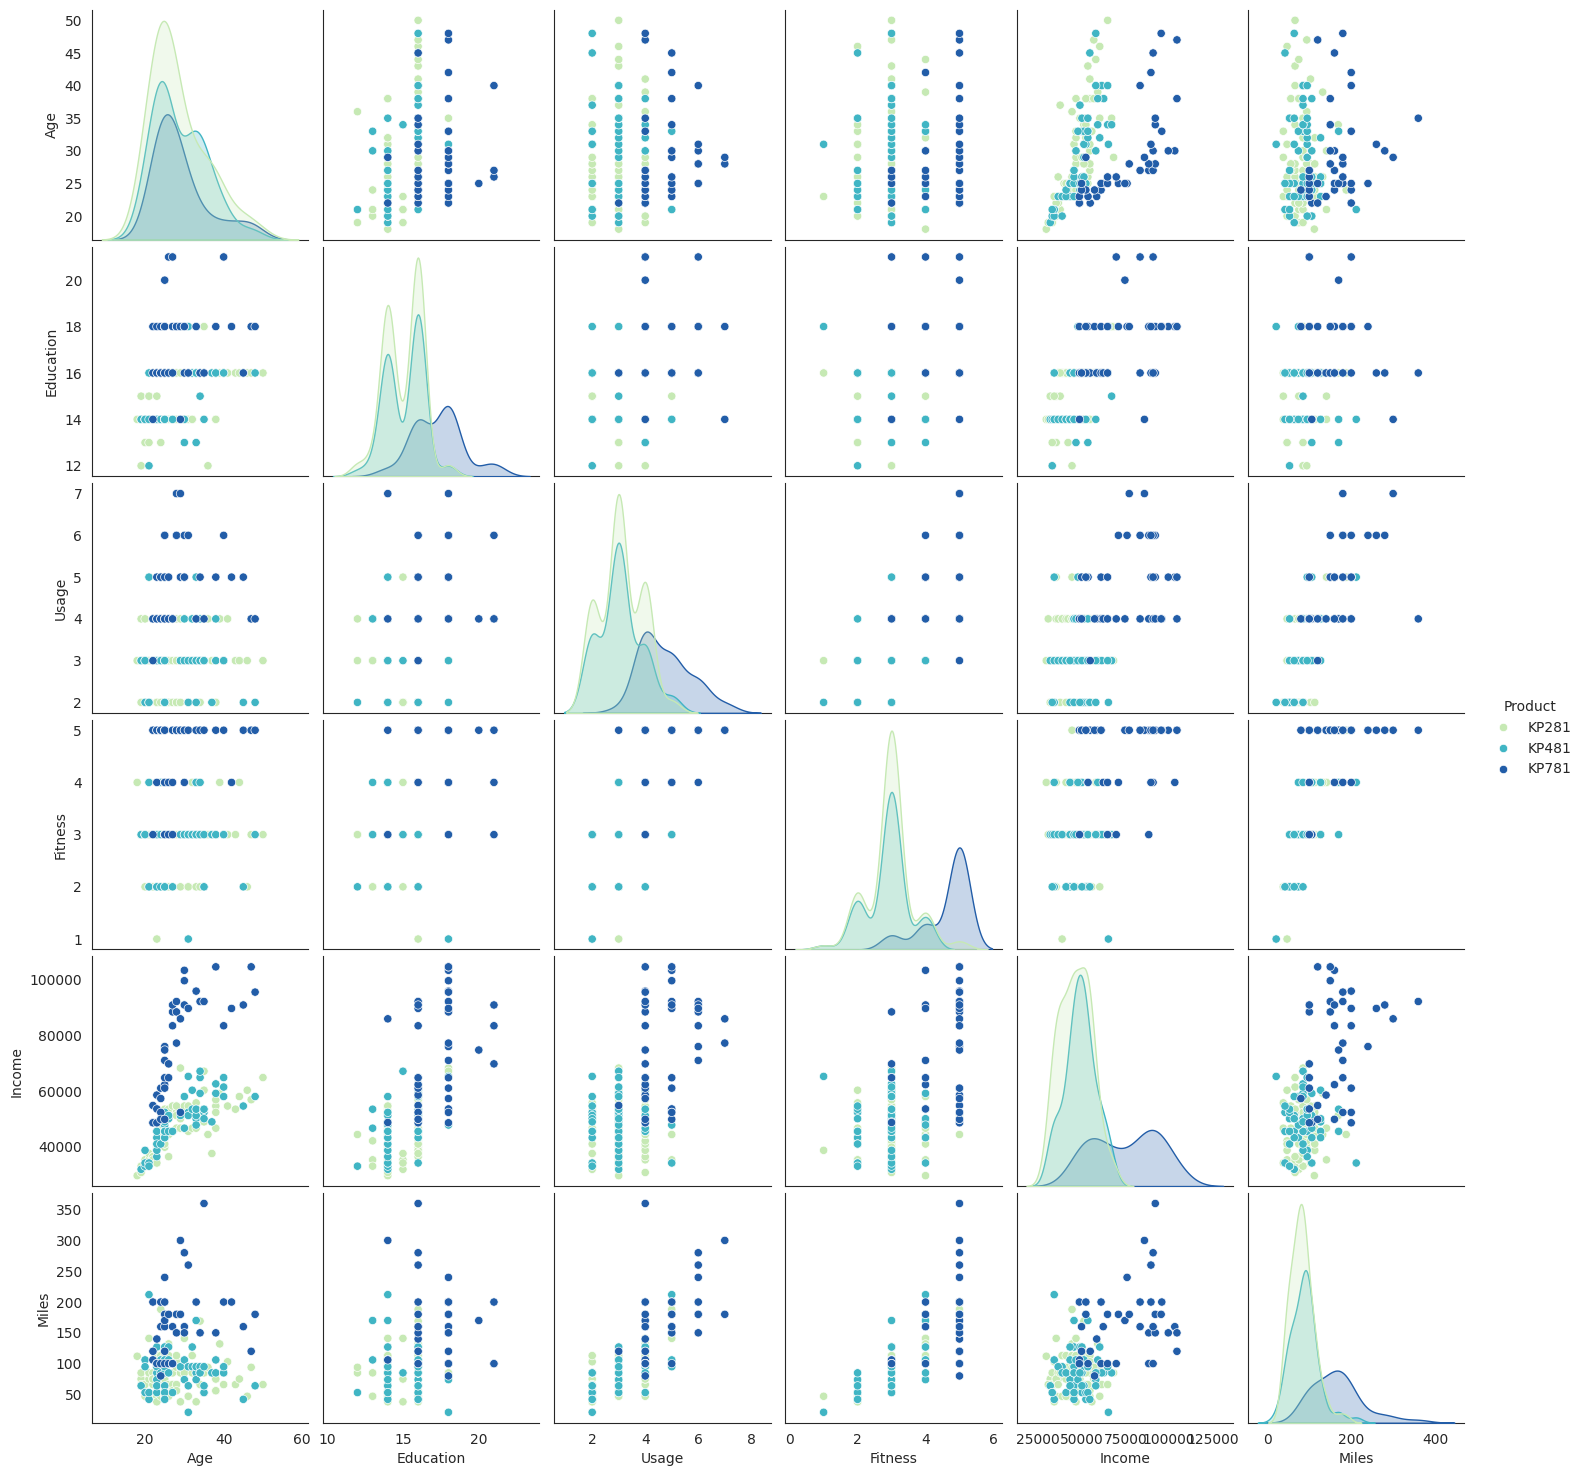

In [ ]:
#Correlation
import copy
df_copy = copy.deepcopy(df)
sns.pairplot(df_copy, hue ='Product', palette= 'YlGnBu')
plt.show()


In [ ]:
# First we need to convert object into int datatype for usage and fitness columns
df_copy['Usage'] = df_copy['Usage'].astype('int')
df_copy['Fitness'] = df_copy['Fitness'].astype('int')
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB


In [ ]:
df_copy = df_copy[df_copy['Product'].apply(lambda x: x.isnumeric())]

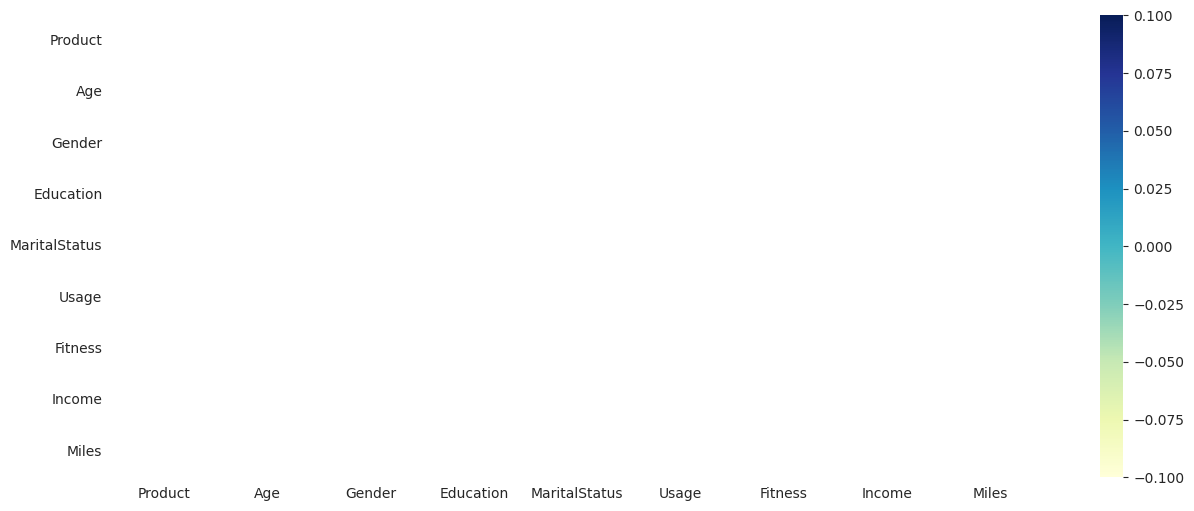

In [ ]:
corr_mat = df_copy.corr()
plt.figure(figsize=(15,6))
sns.heatmap(corr_mat,annot = True, cmap="YlGnBu")
plt.show()

Observations:

From the pair plot we can see Age and Income are positively correlated and heatmap also suggests a strong correlation betwwen them.

Education and Income are highly correlated as its obvious. Education also has significatnt correlation between Fitness rating and Usage of the
treadmill.

Usage is highly correlated with Fitness and Miles as more the usage more the fitness and mileage.


**Customer profiling and recommendation**

**Probability of product purchase w.r.t. Age**

Age Column-

Categorizing the values in age column in 4 different buckets:
1. Young Adult: from 18 - 25
2. Adults: from 26 - 35
3. Middle Aged Adults: 36-45
4. Elder :46 and above

In [ ]:
#binning the age values into categories
bin_range1 = [17,25,35,45,float('inf')]
bin_labels1 = ['Young Adults', 'Adults', 'Middle Aged Adults', 'Elder']
df['age_group'] = pd.cut(df['Age'],bins = bin_range1,labels = bin_labels1)

In [ ]:
pd.crosstab(index =df['Product'],columns = df['age_group'],margins = True,normalize = True ).round(2)

age_group,Young Adults,Adults,Middle Aged Adults,Elder,All
Product,,,,,
KP281,0.19,0.18,0.06,0.02,0.44
KP481,0.16,0.13,0.04,0.01,0.33
KP781,0.09,0.09,0.02,0.01,0.22
All,0.44,0.41,0.12,0.03,1.00


**Insights**
1. The Probability of a treadmill being purchased by a Young Adult(18-25) is 44% .
The conditional probability of purchasing the treadmill model given that the customer is Young Adult is
  For Treadmill model KP281 - 19%,
  For Treadmill model KP481 - 16%,
  For Treadmill model KP781 - 9%
1. The Probability of a treadmill being purchased by a Adult(26-35) is 41% .
The conditional probability of purchasing the treadmill model given that the customer is Adult is -
  For Treadmill model KP281 - 18%,
  For Treadmill model KP481 - 13%,
  For Treadmill model KP781 - 9%,
1. The Probability of a treadmill being purchased by a Middle Aged(36-45) is 12% .
1. The Probability of a treadmill being purchased by a Elder(Above 45) is only 3%

**Probability of product purchase w.r.t. gender**

In [ ]:
pd.crosstab(index =df['Product'],columns = df['Gender'],margins = True,normalize = True ).round(2)

Gender,Female,Male,All
Product,,,
KP281,0.22,0.22,0.44
KP481,0.16,0.17,0.33
KP781,0.04,0.18,0.22
All,0.42,0.58,1.00


1. The Probability of a treadmill being purchased by a female is 42% .
The conditional probability of purchasing the treadmill model given that the customer is female is
For Treadmill model KP281 - 22%,
For Treadmill model KP481 - 16%,
For Treadmill model KP781 - 4%,
1. The Probability of a treadmill being purchased by a male is 58% .
The conditional probability of purchasing the treadmill model given that the customer is male is -
For Treadmill model KP281 - 22%,
For Treadmill model KP481 - 17%,
For Treadmill model KP781 - 18%,


**Probability of product purchase w.r.t. Income**

Income Column-

Categorizing the values in Income column in 4 different buckets:
1. Low Income - Upto 40,000
2. Moderate Income - 40,000 to 60,000
3. High Income - 60,000 to 80,000
4. Very High Income - Above 80,000

In [ ]:
#binning the income values into categories
bin_range3 = [0,40000,60000,80000,float('inf')]
bin_labels3 = ['Low Income','Moderate Income','High Income','Very High Income']
df['income_group'] = pd.cut(df['Income'],bins = bin_range3,labels = bin_labels3)

In [ ]:
 pd.crosstab(index =df['Product'],columns = df['income_group'],margins = True,normalize = True ).round(2)

income_group,Low Income,Moderate Income,High Income,Very High Income,All
Product,,,,,
KP281,0.13,0.28,0.03,0.00,0.44
KP481,0.05,0.24,0.04,0.00,0.33
KP781,0.00,0.06,0.06,0.11,0.22
All,0.18,0.59,0.13,0.11,1.00


1. The Probability of a treadmill being purchased by a customer with Low Income(<40k) is 18% .
The conditional probability of purchasing the treadmill model given that the customer has Low Income is -
For Treadmill model KP281 - 13%,
For Treadmill model KP481 - 5%,
For Treadmill model KP781 - 0%,
1. The Probability of a treadmill being purchased by a customer with Moderate Income(40k - 60k) is 59% .
The conditional probability of purchasing the treadmill model given that the customer has Moderate Income is -
For Treadmill model KP281 - 28%,
For Treadmill model KP481 - 24%,
For Treadmill model KP781 - 6%,
1. The Probability of a treadmill being purchased by a customer with High Income(60k - 80k) is 13%
The conditional probability of purchasing the treadmill model given that the customer has High Income is -
For Treadmill model KP281 - 3%,
For Treadmill model KP481 - 4%,
For Treadmill model KP781 - 6%,
1. The Probability of a treadmill being purchased by a customer with Very High Income(>80k) is 11%
The conditional probability of purchasing the treadmill model given that the customer has High Income is -
For Treadmill model KP281 - 0%,
For Treadmill model KP481 - 0%,
For Treadmill model KP781 - 11%,


**Customer Profiling**

**Based on above analysis**

Probability of purchase of KP281 = 44%

Probability of purchase of KP481 = 33%

Probability of purchase of KP781 = 22%

**Customer Profile for KP281 Treadmill:**

Age of customer mainly between 18 to 35 years with few between 35 to 50 years.

Education level of customer 13 years and above.

Annual Income of customer below USD 60,000.


**Customer Profile for KP481 Treadmill:**

Age of customer mainly between 18 to 35 years with few between 35 to 50 years.

Education level of customer 13 years and above.

Annual Income of customer between USD 40,000 to USD 80,000.

**Customer Profile for KP781 Treadmill:**

Gender - Male

Age of customer between 18 to 35 years.

Education level of customer 15 years and above.

Annual Income of customer USD 80,000 and above.


**Recommendations**

Marketing Campaigns for KP781

The KP781 model exhibits a significant sales disparity in terms of gender, with only 4% of total sales attributed to female customers. To enhance this metric, it is recommended to implement targeted strategies such as offering special promotions and trials exclusively designed for the female customers.

Affordable Pricing and Payment Plans

Given the target customer's age, education level, and income, it's important to offer the KP281 and KP481 Treadmill at an affordable price point. Additionally, consider providing flexible payment plans that allow customers to spread the cost over several months. This can make the treadmill more accessible to customers with varying budgets.

User-Friendly App Integration

Create a user-friendly app that syncs with the treadmill. This app could track users' weekly running mileage, provide real-time feedback on their progress, and offer personalized recommendations for workouts based on their fitness scale and goals.This can enhance the overall treadmill experience and keep users engaged.
